# Exploratory Data Analysis

## Temporal Analysis

*How did reported crime change over time, and how did the COVID period differ from the surrounding years?*


In [2]:
import pandas as pd
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


path = Path.cwd()
while not (path / "src").exists():
    path = path.parent
os.chdir(path)

from src.eda_funcs import (
    seasonal_amplitude,
    relative_difference,
    covid_pct_change,
    column_iqr,
    crime_rate_bump, 
    crime_subplots,
    region_subplots,
    regional_vs_suburb_plot
)


source_path = Path('data/processed')

crime_act = pd.read_csv(source_path / 'crime_act.csv')
crime_act['Date'] = pd.to_datetime(crime_act['Date'], format='%Y-%m-%d')
crime_act['Covid'] = pd.Categorical(crime_act['Covid'], categories=['Pre', 'During', 'Post'], ordered=True)

crime_region = pd.read_csv(source_path / 'crime_region.csv')
crime_region['Date'] = pd.to_datetime(crime_region['Date'], format='%Y-%m-%d')
crime_region['Covid'] = pd.Categorical(crime_region['Covid'], categories=['Pre', 'During', 'Post'], ordered=True)

crime_suburb = pd.read_csv(source_path / 'crime_suburb.csv')
crime_suburb['Date'] = pd.to_datetime(crime_suburb['Date'], format='%Y-%m-%d')
crime_suburb['Covid'] = pd.Categorical(crime_suburb['Covid'], categories=['Pre', 'During', 'Post'], ordered=True)

sns.set_palette('Set2', 6)


### ACT-Wide Analysis
Crime rates across the whole of the ACT between 2014 and 2025 were analysed. They show that many crime rates, including the total crime rate, appeared to be trending downwards over this period. Examination of crime rates at a quarterly granularity show crime rates during Covid to be 'out of trend' in many cases, such as for Family Violence, Burglary, Robbery, and CINs. Examination of crime rate distributions at the Covid period level show more unusual behaviour during Covid for Family Violence, Robbery, Assault, and Homicide. Given the smaller sample size of observations during the Covid period compared to pre- or post-Covid, these findings are less conclusive.

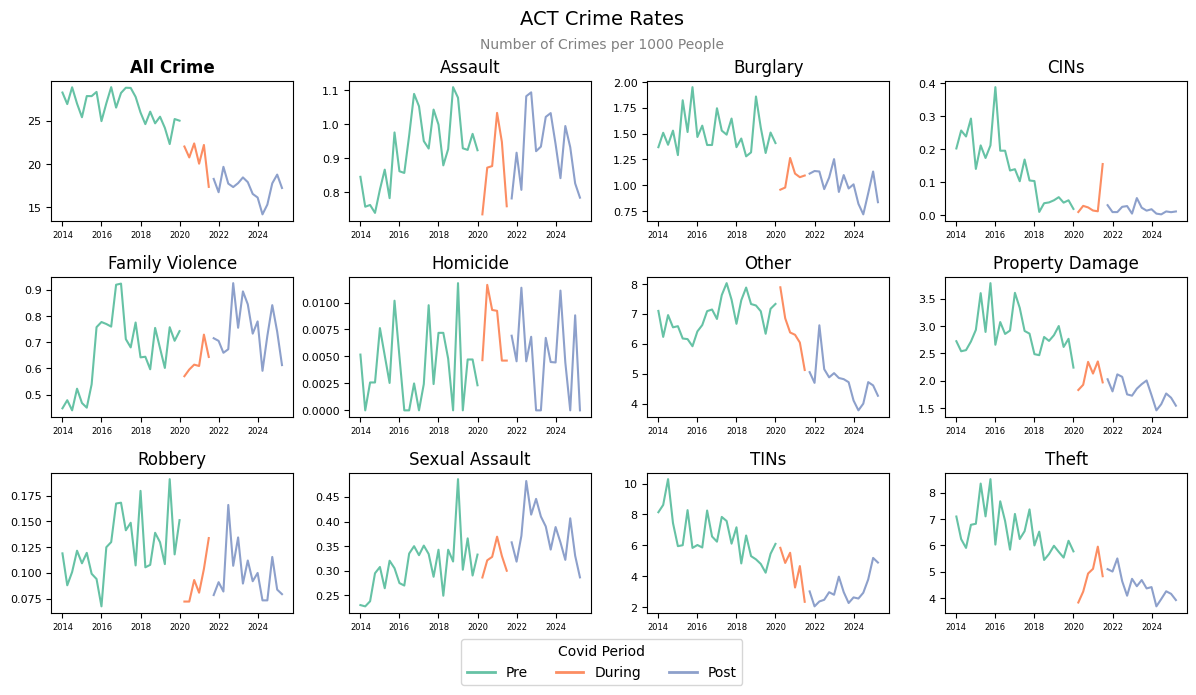

In [3]:
crime_subplots(crime_act, sns.lineplot, 'Date', 'Rate', 'Covid', False, False, legend=False)

plt.suptitle('ACT Crime Rates', fontsize=14)
act_rates_fig = plt.gcf()
act_rates_fig.text(0.5, 0.94, 'Number of Crimes per 1000 People', ha='center', va='top', fontsize=10, color='grey')
plt.tight_layout(rect=[0, 0.07, 1, 0.98])
plt.show()
plt.close('all')

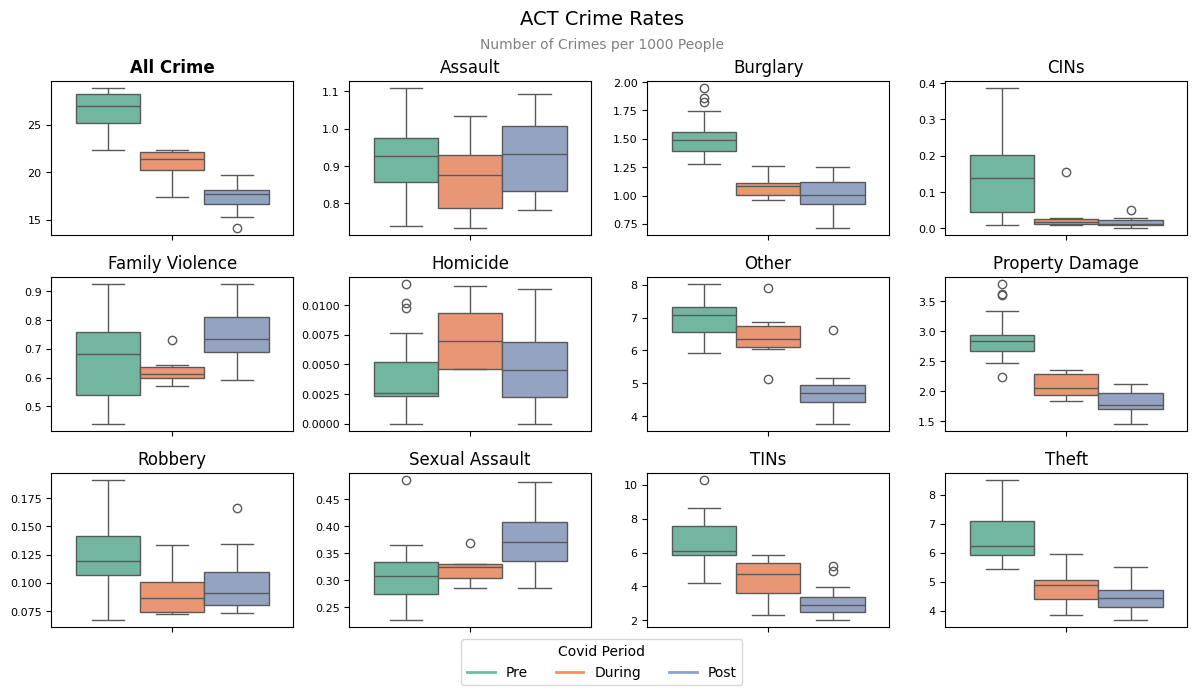

In [4]:
crime_subplots(crime_act, sns.boxplot, None, 'Rate', 'Covid', False, False, legend=False)

plt.suptitle('ACT Crime Rates', fontsize=14)
act_rates_fig = plt.gcf()
act_rates_fig.text(0.5, 0.94, 'Number of Crimes per 1000 People', ha='center', va='top', fontsize=10, color='grey')
plt.tight_layout(rect=[0, 0.07, 1, 0.98])
plt.show()
plt.close('all')

#### Mean Crime Rate Percentage Change
For each crime, the percentage change in mean rate between each the current and preceding Covid period, $P_{c,i}$, was calculated, demonstrating that the temporal behaviour of crime rate differed between crimes. 

$$
P_{c,i} = \frac{\bar{R}_{c, C_i} - \bar{R}_{c, C_{i-1}}}{\bar{R}_{c, C_{i-1}}}
$$

* $c$: crime type (and other grouping variables, such as suburb)
* $C_i$: current Covid period
* $C_{i-1}$: previous Covid period
* $\bar{R}_{c, C_i}$: mean crime rate for current Covid period and variables


The mean crime rate decreased during Covid compared to pre-Covid for all crimes other than Homicide and Sexual Assault. Many crimes also experienced a greater percentage change between these two periods. For most crime types, there was also a decrease in mean crime rates post-Covid compared to during Covid. 


ACT-wide crime rate changes by covid period:
                 Pre-Covid Mean Crime Rate  Covid Mean Crime Rate  \
Crime                                                               
All Crime                        26.611897              20.804168   
Assault                           0.921617               0.871242   
Burglary                          1.507072               1.080334   
CINs                              0.141478               0.040087   
Family Violence                   0.661777               0.627158   
Homicide                          0.004026               0.007344   
Other                             6.939948               6.432820   
Property Damage                   2.877370               2.093715   
Robbery                           0.125512               0.092647   
Sexual Assault                    0.310114               0.322490   
TINs                              6.584830               4.414647   
Theft                             6.538154               

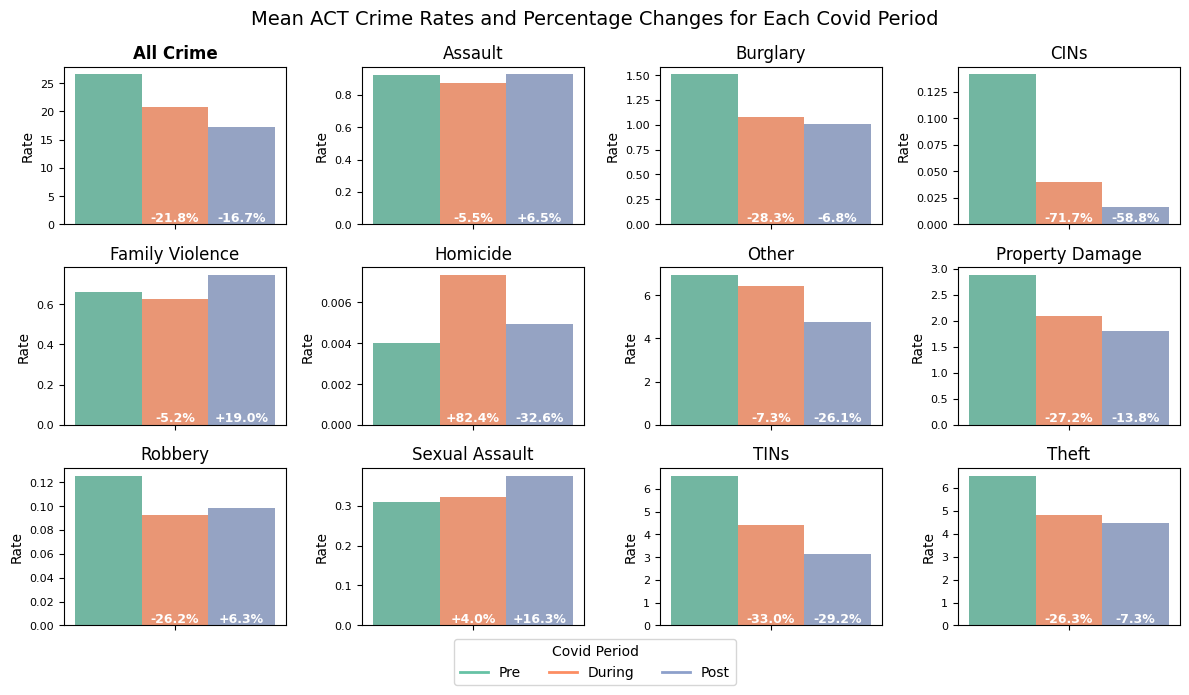

In [5]:
# calculate percentage change during and after covid
print('\nACT-wide crime rate changes by covid period:')
crime_act_pct, act_mean_rate = covid_pct_change(crime_act, ['Crime', 'Rate', 'Covid'])
crime_subplots(crime_act_pct, sns.barplot, None, 'Rate', 'Covid', False, True, legend=False, width=0.9)

fig = plt.gcf()
for i, ax in enumerate(fig.get_axes()):
    #print(round(crime_act_pct.iloc[(3*i)+1, 3], 1))
    changes = [round(crime_act_pct.iloc[(3*i)+1, 3], 1), round(crime_act_pct.iloc[(3*i)+2, 3], 1)]
    str_changes = [f'{x}%' if x < 0 else f'+{x}%' for x in changes]

    ax.text(0.5, 0.02, str_changes[0], transform=ax.transAxes, ha='center', size=9, weight='bold', c='white')
    ax.text(0.8, 0.02, str_changes[1], transform=ax.transAxes, ha='center', size=9, weight='bold', c='white')
plt.suptitle('Mean ACT Crime Rates and Percentage Changes for Each Covid Period', fontsize=14)
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()
plt.close('all')


#### Mean Crime Rate Percentage Change
For each Covid period $C$, the mean crime rate was calculated for each quarter $\bar{R}_{c, C, q}$ and for the period as a whole $\bar{R}_{c, C}$

$$
\bar{R}_{c, C, q} = \frac{1}{n_{c, C, q}} \sum_{i=1}^{n_{c, C, q}} R_{i, c, C, q}
$$

* $c$: crime type (and other grouping variables, such as suburb)
* $C$: Covid period
* $q$: quarter
* $n_{c,C,q}$: the number of observations for variable(s) $c$, COVID period
$C$, and quarter $q$
* $R_{i,c,C,q}$: the crime rate for observation $i$


$$
\bar{R}_{c, C} = \frac{1}{n_{c, C}} \sum_{i=1}^{n_{c, C}} R_{i, c, C}
$$

* $c$: crime type (and other grouping variables, such as suburb)
* $C$: Covid period
* $n_{c,C}$: the number of observations for variable(s) $c$ and COVID period
$C$, and quarter $q$
* $R_{i,c,C}$: the crime rate for observation $i$

The quarterly percentage deviation from the corresponding Covid-period mean, $D_{c,C,q}$, was then calculated.

$$
D_{c,C,q} = \frac{\bar{R}_{c, C, q} - \bar{R}_{c, C}}{\bar{R}_{c, C}} \times 100
$$


Finally, the seasonal amplitude, $A_{c, C}$, was calcualted as the range of the quarterly deviations.

$$
A_{c, C} = \max_{q} D_{c,C,q} - \min_{q} D_{c,C,q}
$$
    
These demonstrate that the temporal behaviour of crime rate differed between crimes. 
The mean crime rate decreased during Covid compared to pre-Covid for all crimes other than Homicide and Sexual Assault. Many crimes also experienced a greater percentage change between these two periods. For most crime types, there was also a decrease in mean crime rates post-Covid compared to during Covid. 

In [6]:
act_seasonal, act_seasonal_amp = seasonal_amplitude(crime_act, ['Crime', 'Quarter', 'Covid'])


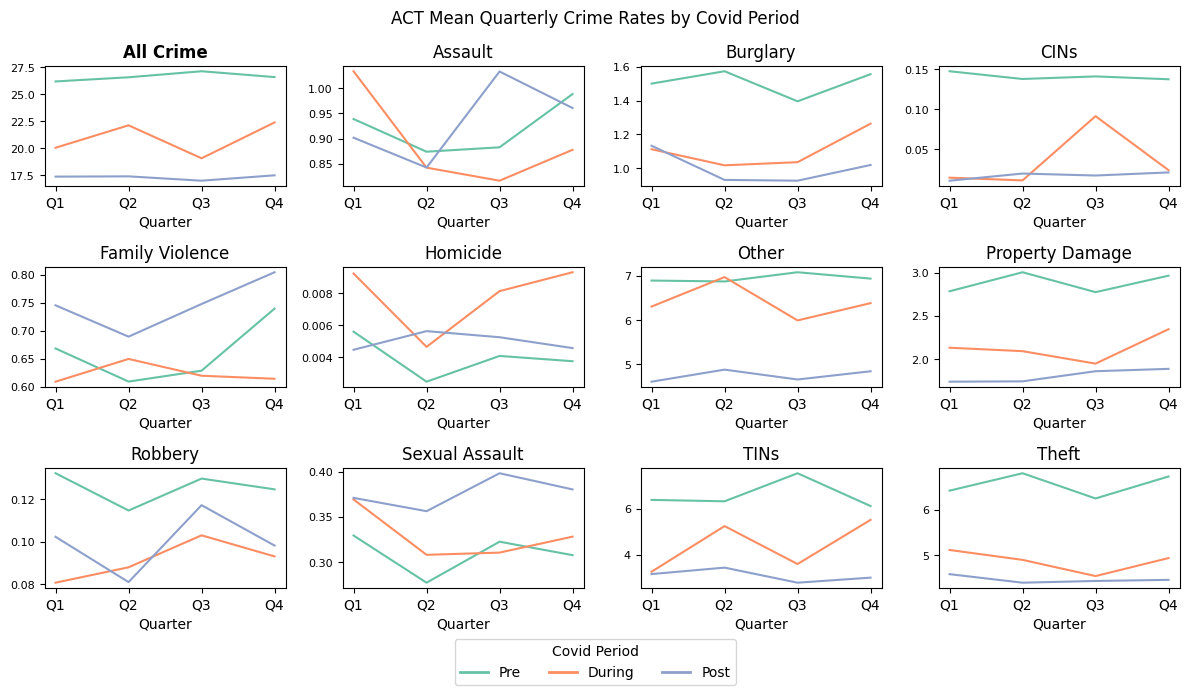

In [7]:
crime_subplots(act_seasonal, sns.lineplot, 'Quarter', 'Mean Quarter Rate', 'Covid', x_label=True, y_label=False, legend=False)
plt.suptitle('ACT Mean Quarterly Crime Rates by Covid Period', fontsize=12)
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()
plt.close('all')

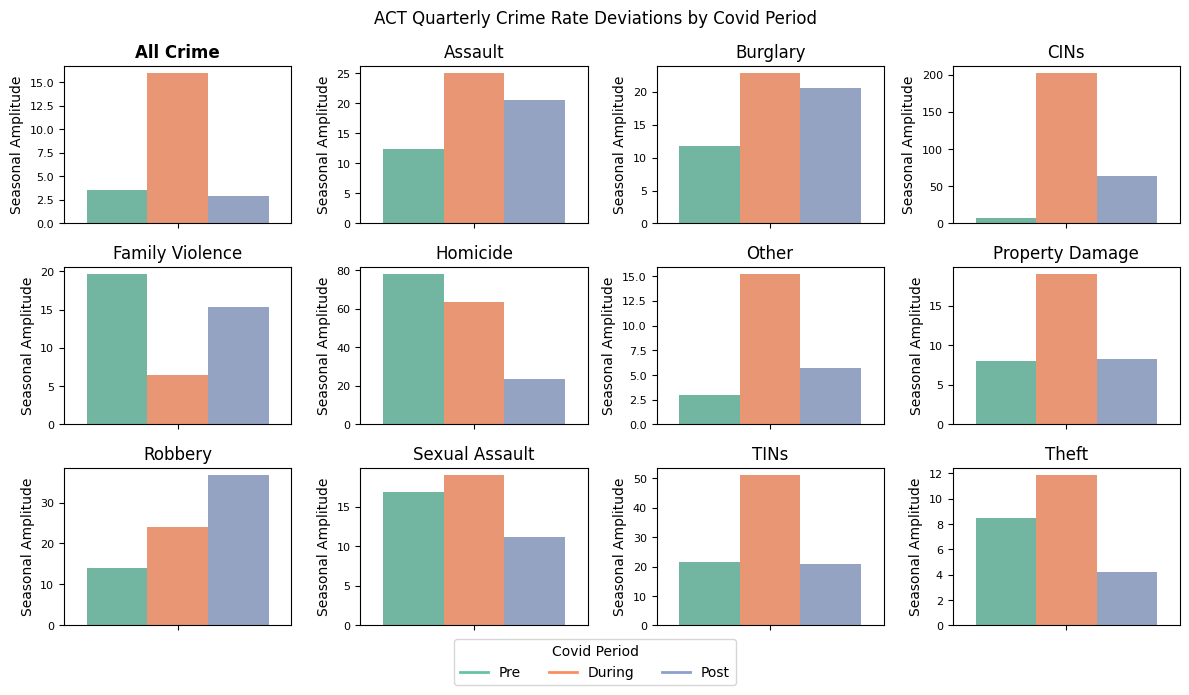

In [8]:
crime_subplots(act_seasonal_amp, sns.barplot, None, 'Seasonal Amplitude', 'Covid', x_label=True, y_label=True, legend=False)
plt.suptitle('ACT Quarterly Crime Rate Deviations by Covid Period', fontsize=12)
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()
plt.close('all')

Covid 
Pre       300
Post      180
During     72
Name: count, dtype: int64
Covid 
Pre       300.0
Post      180.0
During     72.0
Name: count, dtype: float64


In [ ]:
# TODO: add pct change and seasonality equations
#TODO: add boxplot to main py
#TODO: plot rate against something else? scatter plot somehow? -
# TODO: consider mean vs median for pct change
#TODO: visualise covid period counts?